<a href="https://colab.research.google.com/github/nitish36200/Projects/blob/main/loan_approval_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                   Loan Approval Model
Developed a Loan Approval Prediction model using Deep Learning with features like income, credit score, loan amount, and years of employment. Initially, the model suffered from overfitting, achieving 100% training accuracy but failing on test data with only 45% accuracy. Improved the model by applying regularization techniques, dropout, and proper data preprocessing. The optimized model achieved 90–92% accuracy on unseen test data, improving reliability and generalization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
df = pd.read_csv('loan_approval.csv')
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [ ]:
#feature engineering
df['loan_approved'] = df['loan_approved'].astype(int)
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,0
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,0
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,0
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,0
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,0


In [ ]:
# split the data
X = df.drop(columns=['name', 'city', 'points', 'loan_approved'])
X

,income,credit_score,loan_amount,years_employed
0,113810,389,39698,27
1,44592,729,15446,28
2,33278,584,11189,13
3,127196,344,48823,29
4,66048,496,47174,4
...,...,...,...,...
1995,92163,770,12251,13
1996,38799,635,48259,17
1997,41957,763,16752,5
1998,139022,360,24031,35


In [ ]:
y = df.iloc[:,[7]]
y

,loan_approved
0,0
1,0
2,0
3,0
4,0
...,...
1995,1
1996,0
1997,1
1998,0


In [ ]:
print(X.shape)
print(y.shape)

(2000, 4)
(2000, 1)


In [ ]:
#Split the data into X_trian test y_train
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=15,shuffle=True)

In [ ]:
# Feature Scaling the data
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test= ss.transform(X_test)     # No need to transform the y_trian

In [ ]:
# Trian the model using tensorflow and keras
from tensorflow.keras.models import Sequential # Sequential is create a neural nework
from tensorflow.keras.layers import Dense       # it connect the every neuron to previous neuron
from tensorflow.keras.layers import Dropout     # It prevent the overfiting
from tensorflow.keras.layers import ReLU        # It is activation function


In [ ]:
# Create a model
from tensorflow.keras.regularizers import l2
model = Sequential()
model.add(Dense(units=5,activation='relu',kernel_regularizer=l2(0.1)),Dropout(0.5)) # Input Layer
model.add(Dense(units=3,activation='relu'),Dropout(0.20)) # Second layer
#model.add(Dense(units=3,activation='relu'),Dropout(0.15)) #third layer
model.add(Dense(1,activation='sigmoid'),) #Output layer


In [ ]:
# Optimize the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# Use early stoping
import tensorflow.keras as keras
early_stoping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    verbose=2,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [ ]:
print(X_test.shape)

(400, 4)


In [ ]:
# Moddle triang or fitting the model
model_history=model.fit(X_train,y_train,batch_size=10,validation_split=0.2,epochs=50,callbacks=early_stoping)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9164 - loss: 0.2215 - val_accuracy: 0.9250 - val_loss: 0.2237
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9211 - loss: 0.2191 - val_accuracy: 0.9281 - val_loss: 0.2210
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9156 - loss: 0.2175 - val_accuracy: 0.9250 - val_loss: 0.2180
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9187 - loss: 0.2167 - val_accuracy: 0.9250 - val_loss: 0.2184
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9195 - loss: 0.2146 - val_accuracy: 0.9281 - val_loss: 0.2175
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9211 - loss: 0.2140 - val_accuracy: 0.9219 - val_loss: 0.2162
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9250 - loss: 0.2115 - val_accuracy: 0.9312 - val_loss: 0.2146
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9250 - loss: 0.2105 - val_accuracy: 0.

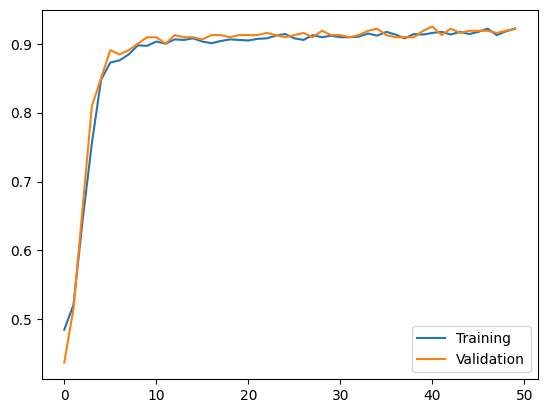

In [ ]:
import matplotlib.pyplot as plt

plt.plot(model_history.history['accuracy'], label='Training')
plt.plot(model_history.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

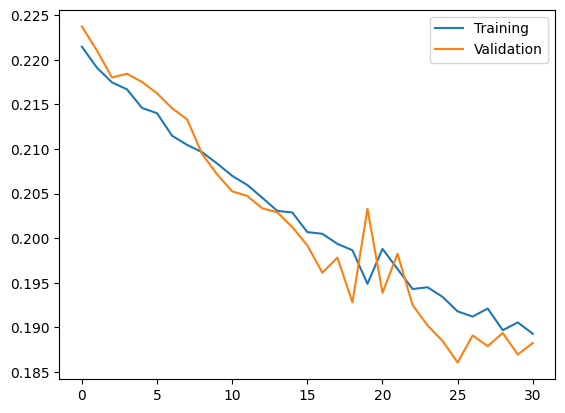

In [ ]:
# Model loss
plt.plot(model_history.history['loss'], label='Training')
plt.plot(model_history.history['val_loss'], label='Validation')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9375 - loss: 0.1983  
Test Accuracy: 0.9375
Test Loss: 0.19825130701065063


In [ ]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_67 (Dense)                │ (10, 5)                │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (10, 3)                │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (10, 1)                │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143 (576.00 B)

 Trainable params: 47 (188.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 96 (388.00 B)

In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred>0.5)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
#check the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
score


0.955

In [ ]:
X.tail()

,income,credit_score,loan_amount,years_employed
1995,92163,770,12251,13
1996,38799,635,48259,17
1997,41957,763,16752,5
1998,139022,360,24031,35
1999,41188,482,31397,6


In [ ]:
new_data = [[92163,770,12251,13]]
data = ss.transform(new_data)
predict = model.predict(data)
num = predict.item()
if predict > 0.5:
  print("loan_approved.\nChance of approval is:",num*100,"%")
else:
  print("Loan not approved.\nChance of approval is:",num*100,"%")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
loan_approved.
Chance of approval is: 95.98252177238464 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
